Want to investigate if using DMD can extract slowly varying bifurcation parameter. 

In [1]:
import os
import sys
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems_new as ds

import models.Neural_ODEs_v2 as nodes

# Generating Test Data


In [132]:
pts = torch.arange(-0.5, -0.2, 0.01)
cartesian_product = torch.cartesian_prod(pts, pts)
init = cartesian_product

In [133]:
cartesian_product.shape

torch.Size([900, 2])

In [134]:
sn = ds.saddlenode()
sn.dadt = 0.01
trajectory = sn.solve(x0 = init, t_span=(0, 20), dt = 0.01, driven=True)

In [139]:
data = trajectory[:, :, 0]

Delay Co-ordinate Embedding of Test Data

In [99]:
dim = 6
data_pts = trajectory.shape[0]

embedded_data = torch.stack([trajectory[i:i+dim,0,0] for i in range(data_pts - dim)])


In [140]:
svd = torch.svd(data)
r = 2
S_r = svd.S[0:r]
U_r = svd.U[:,0:r]
V_r = svd.V[:,0:r]

In [144]:
svd.S

tensor([6.7397e+02, 3.0614e+01, 1.4267e+01, 1.0441e+00, 4.2176e-01, 1.4468e-01,
        3.4139e-02, 4.6131e-03, 3.1340e-03, 9.1532e-04, 3.6540e-04, 3.2137e-04,
        2.5828e-04, 2.0736e-04, 2.0112e-04, 1.7856e-04, 1.7270e-04, 1.6747e-04,
        1.4526e-04, 1.3729e-04, 1.3365e-04, 1.1505e-04, 1.1071e-04, 1.0600e-04,
        9.7186e-05, 8.5259e-05, 8.2402e-05, 8.1379e-05, 7.8170e-05, 7.5756e-05,
        7.4241e-05, 6.5362e-05, 6.3576e-05, 5.4136e-05, 5.2825e-05, 4.4176e-05,
        4.0975e-05, 4.0228e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05, 4.0111e-05,
        4.0111e-05, 4.0111e-05, 4.0111e-

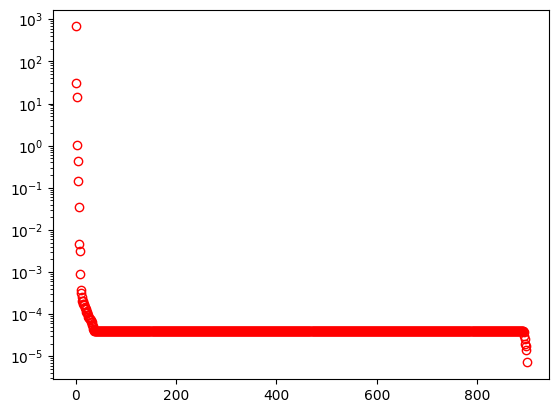

In [145]:
plt.plot(svd.S, linewidth=0, marker='o', mfc='None',color='r')
plt.yscale('log')

In [147]:
svd.V.shape

torch.Size([900, 900])

In [116]:
trajectory[:, 0, 1]

tensor([-5.0000e-01, -4.9990e-01, -4.9980e-01,  ..., -2.8317e-04,
        -1.8315e-04, -8.3164e-05])

In [119]:
svd.U[:-1, 0] - svd.U[1:, 0]

tensor([-1.2914e-04, -1.2675e-04, -1.2432e-04,  ..., -6.7172e-06,
        -6.7218e-06, -6.7293e-06])

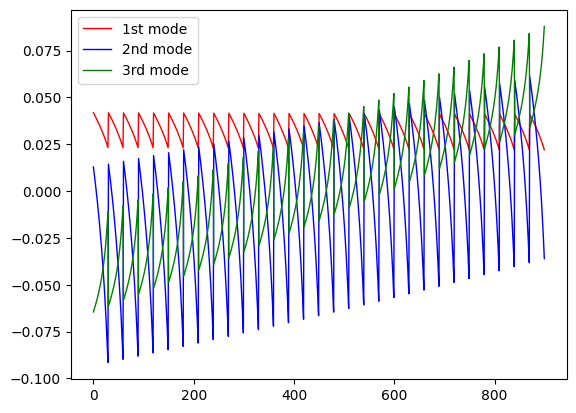

In [148]:
plt.plot(svd.V[:, 0], linewidth=1, marker='', mfc='None', color='r', label='1st mode')
plt.plot(svd.V[:, 1], linewidth=1, marker='', mfc='None', color='b', label='2nd mode')
plt.plot(svd.V[:, 2], linewidth=1, marker='', mfc='None', color='g', label='3rd mode')
plt.legend()

# DMD 

In [151]:
X = data[:, :-1]
Y = data[:, 1:]

In [152]:
X.shape

torch.Size([2000, 899])

In [153]:
torch.svd(X).S

tensor([6.7380e+02, 3.0594e+01, 1.4211e+01, 1.0417e+00, 4.1675e-01, 1.4427e-01,
        3.4035e-02, 4.5964e-03, 3.1227e-03, 9.0298e-04, 3.6504e-04, 3.2129e-04,
        2.5809e-04, 2.0805e-04, 2.0078e-04, 1.7853e-04, 1.7258e-04, 1.6767e-04,
        1.4511e-04, 1.3784e-04, 1.3346e-04, 1.1502e-04, 1.1065e-04, 1.0592e-04,
        9.7253e-05, 8.5169e-05, 8.2008e-05, 8.1803e-05, 7.8446e-05, 7.5396e-05,
        7.4547e-05, 6.6262e-05, 6.3676e-05, 5.4066e-05, 5.2367e-05, 4.3859e-05,
        4.0758e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05, 4.0101e-05,
        4.0101e-05, 4.0101e-05, 4.0101e-

In [154]:
# Want to Fit a matrix A such that Y = AX. This is the DMD matrix. We can do this via least squares regression, which has a closed form solution. We can also add a regularization term to prevent overfitting.
A = Y.T @ X @ torch.linalg.inv(X.T @ X + 1e-5 * torch.eye(X.shape[1]))

In [155]:
A_eigvals, A_eigvecs = torch.linalg.eig(A)

In [156]:
A_eigvals

tensor([-5.9176e+01+0.0000j,  5.6511e+01+0.0000j, -3.2827e+01+32.5523j,
        -3.2827e+01-32.5523j,  4.8002e+01+0.0000j, -4.1662e+01+1.9056j,
        -4.1662e+01-1.9056j, -1.5417e+01+40.5392j, -1.5417e+01-40.5392j,
        -3.6917e+01+15.1078j, -3.6917e+01-15.1078j, -3.8248e+01+8.2950j,
        -3.8248e+01-8.2950j, -3.1685e+01+22.7984j, -3.1685e+01-22.7984j,
        -2.9447e+01+26.1411j, -2.9447e+01-26.1411j, -3.4916e+01+13.8269j,
        -3.4916e+01-13.8269j,  3.6300e+01+23.7394j,  3.6300e+01-23.7394j,
        -3.2572e+01+17.2135j, -3.2572e+01-17.2135j, -2.4986e+01+28.4963j,
        -2.4986e+01-28.4963j,  9.3080e+00+39.5211j,  9.3080e+00-39.5211j,
        -2.3153e+01+30.4192j, -2.3153e+01-30.4192j,  3.2370e+01+24.6015j,
         3.2370e+01-24.6015j,  4.1343e+00+38.9438j,  4.1343e+00-38.9438j,
        -2.9280e+01+22.0796j, -2.9280e+01-22.0796j,  2.0730e+01+34.0979j,
         2.0730e+01-34.0979j,  2.1740e+01+33.4037j,  2.1740e+01-33.4037j,
        -2.2687e+00+38.4732j, -2.2687e+00-38.

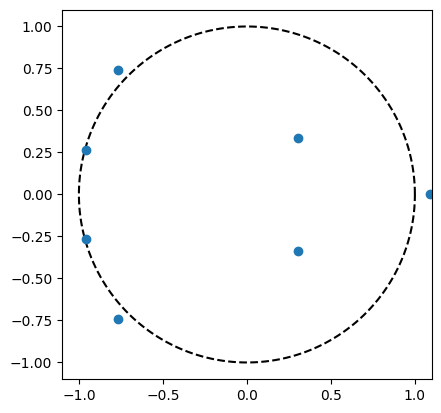

In [158]:
# ...existing code...


ax = plt.gca()  # use current axes}

# Unit circle centered at origin
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1.5, label='Unit circle')

# Keep circle round and visible
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(min(ax.get_xlim()[0], -1.1), max(ax.get_xlim()[1], 1.1))
ax.set_ylim(min(ax.get_ylim()[0], -1.1), max(ax.get_ylim()[1], 1.1))

# Optional
ax.plot(A_eigvals.real, A_eigvals.imag, 'o')


# ...existing code...

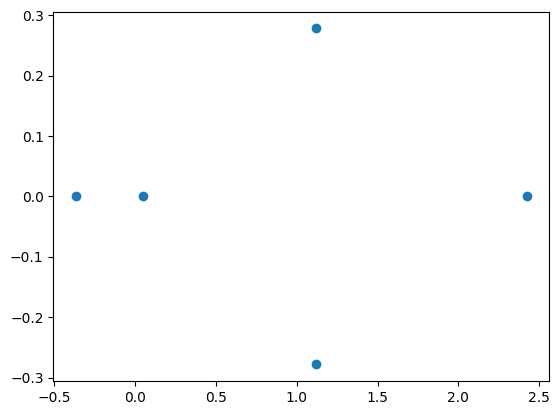

In [24]:
plt.plot(A_eigvals.real, A_eigvals.imag, 'o')